# YOLO Fine-tuning on Solar Imagery — [LSDO dataset](https://dataverse.harvard.edu/dataverse/lsdo)
Author: Juan Esteban Agudelo Ortiz

Email: juan.es.agor@gmail.com

---

This notebook fine-tunes YOLO11n on a three-day sample of the
[LSDO dataset](https://dataverse.harvard.edu/dataverse/lsdo)
from the Harvard Dataverse. The goal is not to produce a publication-ready
model, but to demonstrate that scientific datasets with bounding box
annotations can be used directly to train object detectors — the same
technique used in the previous notebook on VisDrone.

The full [LSDO dataset](https://dataverse.harvard.edu/dataverse/lsdo)
covers SDO solar imagery from January 2012 to December 2014, containing
several hundred thousand annotated solar events across four event types
(AR, CH, FL, SG) and multiple AIA wavelengths (94Å, 131Å, 171Å, 193Å,
211Å). The dataset was published in Scientific Data (Kucuk et al., 2017,
doi:10.1038/sdata.2017.96). Here we use only the three-day sample
(doi:10.7910/DVN/8XRUDT) to demonstrate feasibility.

### Dataset (this notebook)
- **LSDO sample**: 322 images from the Solar Dynamics Observatory (SDO)
- **4 classes**: Active Regions (AR), Filaments (FL), Coronal Holes (CH), Sigmoids (SG)
- **Coverage**: Three consecutive days (2013-01-01 to 2013-01-03)
- **Image size**: 4096×4096 pixels, AIA channels 171Å and 193Å

### Important limitations
1. The sample covers only three consecutive days. This means the train/val
   split has severe **temporal data leakage** — solar features visible in
   training images likely appear in validation images as well. Results
   should not be interpreted as generalizable performance.
2. This notebook is explicitly exploratory. The results demonstrate
   feasibility, not publication-ready performance.
3. A rigorous version of this experiment would require a dataset spanning
   multiple solar rotations (~27 days each) to ensure temporal independence
   between train and val splits.

### Minimum computational resources for a publication-ready experiment

Working with the full [LSDO dataset](https://dataverse.harvard.edu/dataverse/lsdo)
(2012-2014, multiple wavelengths, ~70,000 images/day from SDO) at
4096×4096 resolution would require:

| Resource | Minimum estimate | Notes |
|---|---|---|
| Storage | ~10-20 TB | Full image archive across all wavelengths and three years |
| GPU VRAM | 40 GB | A100 or equivalent — 4096px images at reasonable batch size |
| Training time | 2-4 weeks | 100+ epochs on a multi-GPU setup |
| RAM | 128 GB | Image loading and preprocessing at full resolution |

A more practical approach for a paper would be to work at a single
wavelength (e.g. 171Å), downsample to 1024×1024, and use a temporally
stratified split ensuring train and val images are at least one solar
rotation (~27 days) apart. Under those constraints the storage requirement
drops to ~1-2 TB and training to a few days on a single A100.

> **Running on Kaggle?** Before pushing this notebook, update the
> `kaggle.yml` in `code/` to point to this notebook:
>
> ```yaml
> code_file: 3-Yolo_solar_data-SDO/1-yolo_for_solar_physics.ipynb
> ```
>
> Also make sure to add the `lsdo-sample` dataset to your Kaggle notebook
> input before running — see Section 2 for instructions.

## 0. Install dependencies

In [1]:
# Run only if not already installed
!pip install ultralytics opencv-python matplotlib numpy pandas shapely pillow requests scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.5 MB/s eta 0:00:00


## 1. Imports and configuration

In [2]:
import os
import requests
from zipfile import ZipFile
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from PIL import Image
from shapely import wkt
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

# Datos de Ciencia color palette
PALETTE = {
    "bg":     "#0D1117",
    "orange": "#E85D24",
    "amber":  "#F5A623",
    "yellow": "#FCDE5A",
    "white":  "#FFFFFF",
    "gray":   "#334155",
}

# Solar event classes
CLASS_MAP = {"AR": 0, "FL": 1, "CH": 2, "SG": 3}
CLASS_COLORS = {
    "AR": "#E85D24",  # orange  — Active Regions
    "FL": "#FCDE5A",  # yellow  — Filaments
    "CH": "#38BDF8",  # cyan    — Coronal Holes
    "SG": "#A78BFA",  # purple  — Sigmoids
}
IMG_SIZE = 4096

# Detect environment
IN_KAGGLE = os.path.exists("/kaggle/working")

if IN_KAGGLE:
    MODELS_DIR = Path("/kaggle/working/models")
    DATA_DIR   = Path("/kaggle/working/data")
    OUT_DIR    = Path("/kaggle/working/outputs")
else:
    MODELS_DIR = Path("../models")
    DATA_DIR   = Path("../data")
    OUT_DIR    = Path("outputs")

MODELS_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

print(f"Environment : {'Kaggle' if IN_KAGGLE else 'Local'}")
print(f"Models dir  : {MODELS_DIR.resolve()}")
print(f"Data dir    : {DATA_DIR.resolve()}")
print("Configuration ready ✓")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Environment : Kaggle
Models dir  : /kaggle/working/models
Data dir    : /kaggle/working/data
Configuration ready ✓


## 2. Fetch the data

The three-day sample is hosted on Harvard Dataverse
(doi:10.7910/DVN/8XRUDT). The download includes two nested zip files:
one for the JPEG2000 images and one for the annotation files.

**If running locally:** uncomment and run the download cell below. The
data will be saved to `../data/sdo_dataverse/`. Then to use it on Kaggle,
zip the downloaded folder and upload it as a Kaggle Dataset:

```bash
zip -r lsdo-sample.zip ../data/sdo_dataverse/
```

Then go to https://www.kaggle.com/datasets → **New Dataset**, upload
`lsdo-sample.zip` and name it `lsdo-sample`. In your Kaggle notebook go
to **Input** → search `lsdo-sample` → add it. Kaggle decompresses it
automatically and makes it available at `/kaggle/input/lsdo-sample/`.

**If running on Kaggle:** make sure the `lsdo-sample` dataset is added
to your notebook input before running the path setup cell.

In [3]:
# ── Local download — uncomment if running locally ──────────────────────
# Run this cell once to download the data locally. After downloading,
# zip and upload to Kaggle as described above, then comment it back out.
#
# SERVER_URL    = "https://dataverse.harvard.edu"
# PERSISTENT_ID = "doi:10.7910/DVN/8XRUDT"
# url = f"{SERVER_URL}/api/access/dataset/:persistentId/?persistentId={PERSISTENT_ID}"
#
# print("Downloading LSDO sample from Harvard Dataverse...")
# r = requests.get(url)
# r.raise_for_status()
#
# with ZipFile(BytesIO(r.content)) as zf:
#     zf.extractall(DATA_DIR / "sdo_dataverse")
# print("Outer zip extracted ✓")
#
# def extract_and_delete(zip_path, extract_folder):
#     with ZipFile(zip_path) as zf:
#         zf.extractall(extract_folder)
#     os.remove(zip_path)
#
# for name in ["LSDO_Sample_Images", "LSDO_Sample_Parameters"]:
#     extract_and_delete(
#         zip_path=DATA_DIR / "sdo_dataverse" / "sample" / f"{name}.zip",
#         extract_folder=DATA_DIR / "sdo_dataverse" / "sample" / name,
#     )
# print("Inner zips extracted ✓")
#
# # After downloading, zip and upload to Kaggle:
# # zip -r lsdo-sample.zip ../data/sdo_dataverse/

> **Kaggle users:** make sure the `lsdo-sample` dataset is added to your
> notebook input before running the cell below. Go to **Input** on the
> right panel → search `lsdo-sample` → add it. If the dataset does not
> exist yet, follow the download and upload instructions above first.

In [4]:
# ── Path setup — works for both Kaggle and local ───────────────────────
if IN_KAGGLE:
    DATA_DIR_SDO  = Path("/kaggle/input/datasets/juanessao2000/lsdo-sample/sdo_dataverse")
else:
    DATA_DIR_SDO  = DATA_DIR / "sdo_dataverse"

SAMPLE_FOLDER = DATA_DIR_SDO / "sample"
IMG_BASE      = SAMPLE_FOLDER / "LSDO_Sample_Images"

print(f"Data dir    : {DATA_DIR_SDO}")
print(f"Images base : {IMG_BASE}")
print(f"Exists      : {IMG_BASE.exists()}")

Data dir    : /kaggle/input/datasets/juanessao2000/lsdo-sample/sdo_dataverse
Images base : /kaggle/input/datasets/juanessao2000/lsdo-sample/sdo_dataverse/sample/LSDO_Sample_Images
Exists      : True


## 3. Dataset exploration

The LSDO sample contains two annotation files:

- `sample_event_records.txt`: one row per solar event, with event type,
  bounding box as a WKT polygon, and references to the start, middle, and
  end images of each event.
- `sample_event_file_name_paths.txt`: maps each image filename to its
  relative path within the dataset.

We load both files, inspect the class distribution, and visualize
representative images with their bounding boxes before building the
training dataset.

In [5]:
events = pd.read_csv(
    SAMPLE_FOLDER / "sample_event_records.txt",
    sep="\t",
)

files = pd.read_csv(
    SAMPLE_FOLDER / "sample_event_file_name_paths.txt",
    sep="\t", header=None, names=["filename", "rel_path"],
).set_index("filename")

print(f"Events : {len(events)} rows")
print(f"Images : {len(files)} unique files")
print(f"\nColumns: {events.columns.tolist()}")

Events : 714 rows
Images : 322 unique files

Columns: ['id', 'event_type', 'start_time', 'end_time', 'channel', 'bbox', 'sfilename', 'mfilename', 'efilename', 'frm_name']


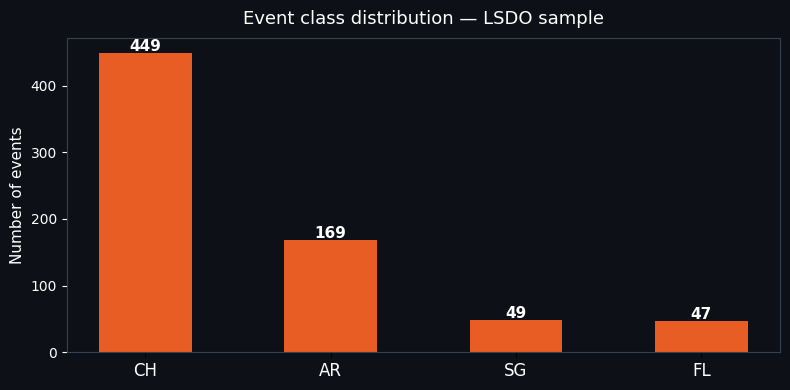

Figure saved ✓


In [6]:
# Class distribution
class_counts = events["event_type"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4), facecolor=PALETTE["bg"])
ax.set_facecolor(PALETTE["bg"])

bars = ax.bar(
    class_counts.index,
    class_counts.values,
    color=PALETTE["orange"],
    edgecolor="none",
    width=0.5,
)
for bar, val in zip(bars, class_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(val),
        ha="center", color=PALETTE["white"],
        fontsize=11, fontweight="bold",
    )

ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(class_counts.index, color=PALETTE["white"], fontsize=12)
ax.tick_params(axis="y", colors=PALETTE["white"])
ax.spines[:].set_color(PALETTE["gray"])
ax.set_ylabel("Number of events", color=PALETTE["white"], fontsize=11)
ax.set_title("Event class distribution — LSDO sample",
             color=PALETTE["white"], fontsize=13, pad=10)

plt.tight_layout()
fig.savefig(OUT_DIR / "class_distribution.png", dpi=150,
            bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("Figure saved ✓")

In [7]:
def parse_bbox(wkt_str):
    geom = wkt.loads(wkt_str)
    xmin, ymin, xmax, ymax = geom.bounds
    return xmin, ymin, xmax - xmin, ymax - ymin


def plot_sample_image(filename, events_df, files_df, ax):
    rel_path = files_df.loc[filename, "rel_path"].lstrip("./")
    image = np.array(Image.open(IMG_BASE / rel_path))

    ax.imshow(image, cmap="gray", origin="upper")

    # Show ALL events referencing this image — s, m, or e filename
    subset = events_df[
        (events_df["sfilename"] == filename) |
        (events_df["mfilename"] == filename) |
        (events_df["efilename"] == filename)
    ]

    legend_handles = {}
    for _, row in subset.iterrows():
        xmin, ymin, w, h = parse_bbox(row["bbox"])
        color = CLASS_COLORS.get(row["event_type"], "#FFFFFF")
        rect = patches.Rectangle(
            (xmin, ymin), w, h,
            linewidth=1.5, edgecolor=color, facecolor="none",
        )
        ax.add_patch(rect)
        if row["event_type"] not in legend_handles:
            legend_handles[row["event_type"]] = patches.Patch(
                edgecolor=color, facecolor="none",
                label=row["event_type"],
            )

    ax.legend(
        handles=legend_handles.values(),
        loc="upper right", fontsize=9,
        facecolor=PALETTE["bg"], labelcolor=PALETTE["white"],
    )
    ax.set_title(filename[:40], color=PALETTE["white"], fontsize=8)
    ax.axis("off")

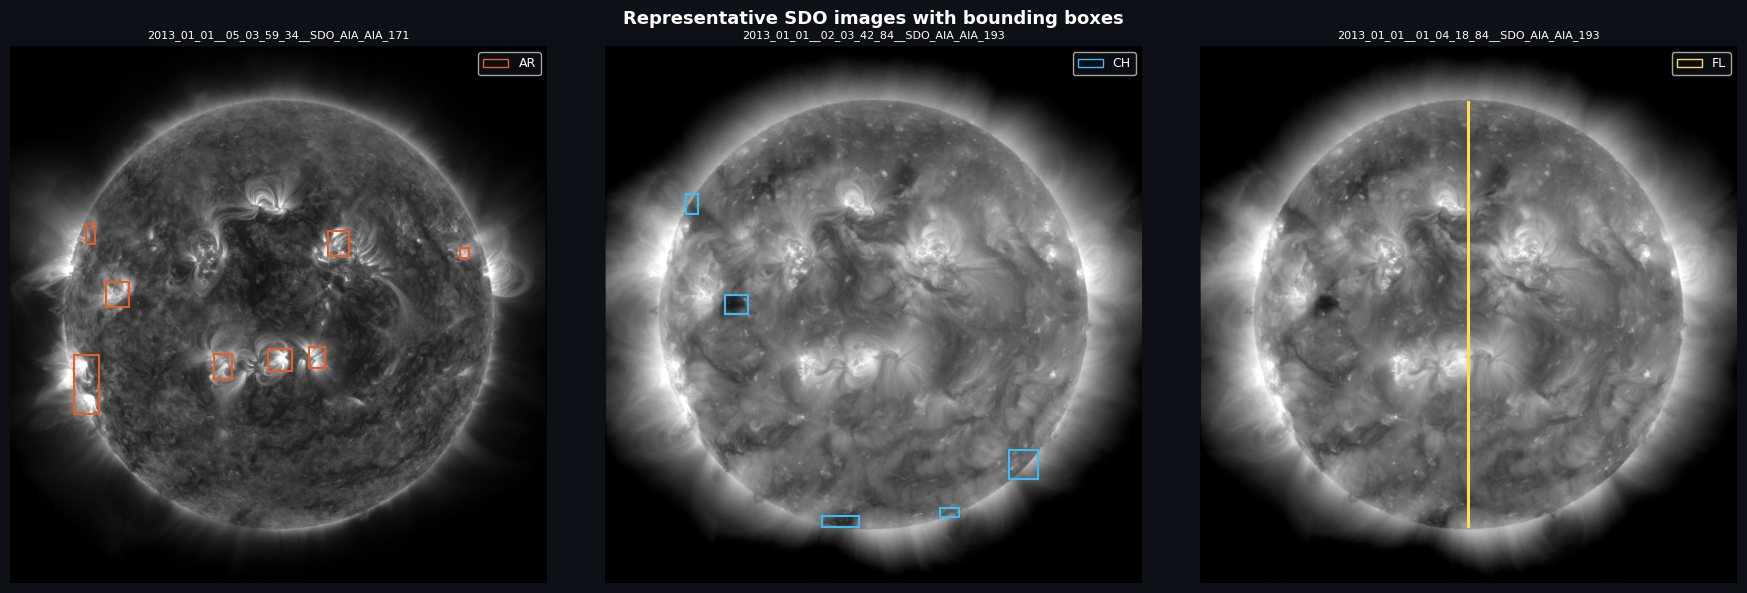

Figure saved ✓


In [8]:
# Select one representative image per major class.
# The plot_sample_image function shows ALL events referencing
# that image — whether as start, middle, or end image —
# regardless of how the image was selected here.
sample_filenames = []
for cls in ["AR", "CH", "FL"]:
    match = events[events["event_type"] == cls]["mfilename"].iloc[0]
    if match in files.index:
        sample_filenames.append(match)

# Deduplicate in case the same image appears for multiple classes
sample_filenames = list(dict.fromkeys(sample_filenames))

fig, axes = plt.subplots(1, len(sample_filenames),
                          figsize=(18, 6), facecolor=PALETTE["bg"])
for ax, fname in zip(axes, sample_filenames):
    plot_sample_image(fname, events, files, ax)

fig.suptitle("Representative SDO images with bounding boxes",
             color=PALETTE["white"], fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "sample_images.png", dpi=150,
            bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("Figure saved ✓")

## 4. Dataset construction

### Image-to-events mapping

Each image in the dataset can be referenced by multiple events — as the
start, middle, or end image of any event occurring at that time. We build
a mapping from each unique image to all events that reference it,
regardless of whether the image is the start, middle, or end of each event.
This ensures every image has all its bounding boxes, analogous to how
VisDrone images contain multiple object classes simultaneously.

In [9]:
image_to_events = {}
for _, row in events.iterrows():
    for col in ["sfilename", "mfilename", "efilename"]:
        fname = row[col]
        if fname not in image_to_events:
            image_to_events[fname] = []
        image_to_events[fname].append({
            "event_type": row["event_type"],
            "bbox":       row["bbox"],
        })

# Keep only images that exist in the files index
image_to_events = {
    k: v for k, v in image_to_events.items()
    if k in files.index
}

print(f"Unique images with at least one event: {len(image_to_events)}")
print(f"Average events per image: {np.mean([len(v) for v in image_to_events.values()]):.1f}")
print(f"Max events in one image : {max(len(v) for v in image_to_events.values())}")

Unique images with at least one event: 322
Average events per image: 6.7
Max events in one image : 200


Images with more than one class: 1
Example: 2013_01_02__12_05_56_62__SDO_AIA_AIA_131
['FL', 'SG']


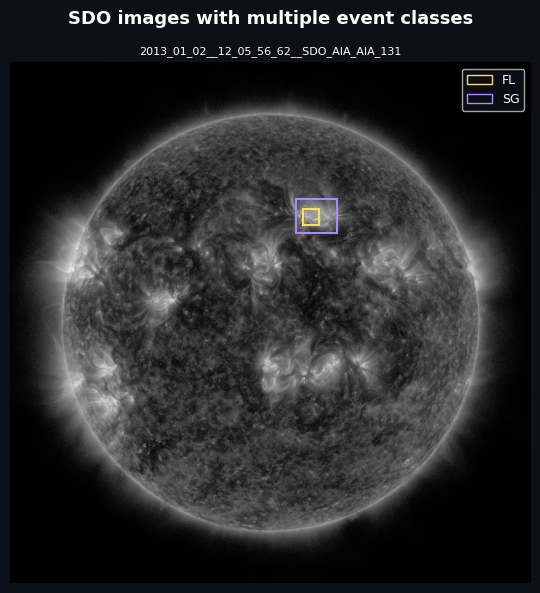

Figure saved ✓


In [10]:
# Find images with more than one event class simultaneously
multi_class = {
    fname: evs for fname, evs in image_to_events.items()
    if len(set(e["event_type"] for e in evs)) > 1
}
print(f"Images with more than one class: {len(multi_class)}")
example = list(multi_class.keys())[0]
print(f"Example: {example}")
print([e["event_type"] for e in multi_class[example]])

# Select up to 3 images with multiple classes for visualization
sample_filenames = list(dict.fromkeys(list(multi_class.keys())[:3]))

fig, axes = plt.subplots(1, len(sample_filenames),
                          figsize=(6 * len(sample_filenames), 6),
                          facecolor=PALETTE["bg"])

# Ensure axes is always iterable
if len(sample_filenames) == 1:
    axes = [axes]

for ax, fname in zip(axes, sample_filenames):
    plot_sample_image(fname, events, files, ax)

fig.suptitle("SDO images with multiple event classes",
             color=PALETTE["white"], fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "sample_images_multiclass.png", dpi=150,
            bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("Figure saved ✓")

### Train/val split — temporal

For time-series scientific data, a random split would mix images from the
same solar rotation into both train and val, producing severe data leakage.
We use a temporal split instead: the first 80% of images by timestamp go
to train, the last 20% to val.

### Data leakage warning

Even with a temporal split, this sample covers only three consecutive days
(2013-01-01 to 2013-01-03). Solar features such as Active Regions have
lifetimes of days to weeks — a feature visible on day 1 will almost
certainly appear on day 3. The train and val sets are therefore not
independent. Results should not be interpreted as generalizable performance.

A rigorous split would require data spanning multiple solar rotations
(~27 days each), with train and val images separated by at least one full
rotation to ensure the same physical features do not appear in both splits.

In [11]:
# Sort images by timestamp embedded in filename
all_filenames = sorted(image_to_events.keys())

split_idx   = int(len(all_filenames) * 0.8)
train_files = all_filenames[:split_idx]
val_files   = all_filenames[split_idx:]

print(f"Train images: {len(train_files)}")
print(f"Val images  : {len(val_files)}")
print(f"Train range : {train_files[0][:19]}  →  {train_files[-1][:19]}")
print(f"Val range   : {val_files[0][:19]}  →  {val_files[-1][:19]}")

Train images: 257
Val images  : 65
Train range : 2013_01_01__00_03_4  →  2013_01_02__12_05_5
Val range   : 2013_01_02__12_08_4  →  2013_01_03__02_48_2


### Image conversion and label generation

SDO images are in JPEG2000 format (`.jp2`), which YOLO cannot process
directly. We convert each image to PNG and replicate the single grayscale
channel across all three RGB channels — this preserves all pixel
information while satisfying YOLO's input requirements.

Bounding box coordinates in the dataset are stored as WKT polygons in
absolute pixel coordinates. We convert them to YOLO format: normalized
center coordinates and dimensions relative to image size.

$$cx = \frac{x_{min} + x_{max}}{2 \cdot W}, \quad
  cy = \frac{y_{min} + y_{max}}{2 \cdot H}, \quad
  w  = \frac{x_{max} - x_{min}}{W}, \quad
  h  = \frac{y_{max} - y_{min}}{H}$$

In [12]:
YOLO_DIR = OUT_DIR / "yolo_dataset"

def parse_bbox_yolo(wkt_str, max_relative_size=0.8):
    geom = wkt.loads(wkt_str)
    xmin, ymin, xmax, ymax = geom.bounds
    cx = (xmin + xmax) / 2 / IMG_SIZE
    cy = (ymin + ymax) / 2 / IMG_SIZE
    w  = (xmax - xmin) / IMG_SIZE
    h  = (ymax - ymin) / IMG_SIZE
    if w > max_relative_size or h > max_relative_size:
        return None
    return cx, cy, w, h


def build_split(filenames, split_name):
    img_out = YOLO_DIR / "images" / split_name
    lbl_out = YOLO_DIR / "labels" / split_name

    # Skip if split already exists and has the expected number of images
    existing = list(img_out.glob("*.png")) if img_out.exists() else []
    if len(existing) == len(filenames):
        print(f"{split_name}: already exists ({len(existing)} images) — skipping ✓")
        return

    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    skipped  = 0
    filtered = 0
    for fname in filenames:
        rel_path = files.loc[fname, "rel_path"].lstrip("./")
        jp2_path = IMG_BASE / rel_path

        if not jp2_path.exists():
            skipped += 1
            continue

        # Convert JP2 → PNG (grayscale → RGB)
        img = Image.open(jp2_path).convert("RGB")
        img.save(img_out / f"{fname}.png")

        # Deduplicate and filter degenerate bounding boxes
        seen = set()
        label_lines = []
        for event in image_to_events[fname]:
            cls = CLASS_MAP.get(event["event_type"])
            if cls is None:
                continue
            result = parse_bbox_yolo(event["bbox"])
            if result is None:
                filtered += 1
                continue
            cx, cy, w, h = result
            key = (cls, round(cx, 4), round(cy, 4))
            if key not in seen:
                seen.add(key)
                label_lines.append(f"{cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

        (lbl_out / f"{fname}.txt").write_text("\n".join(label_lines))

    print(f"{split_name}: {len(filenames) - skipped} images written, "
          f"{skipped} skipped, {filtered} degenerate boxes filtered")


build_split(train_files, "train")
build_split(val_files,   "val")
print("Dataset construction complete ✓")

train: 257 images written, 0 skipped, 0 degenerate boxes filtered
val: 65 images written, 0 skipped, 0 degenerate boxes filtered
Dataset construction complete ✓


## 5. YOLO configuration

### Image size

SDO images are 4096×4096 pixels. Running YOLO at full resolution would
require prohibitive VRAM — a single image at 4096px occupies ~192MB as
a float32 tensor. We use `imgsz=1024` as a compromise: large enough to
preserve the spatial detail needed to detect solar features, small enough
to fit in GPU memory at a reasonable batch size.

$$\text{VRAM per image} \approx \frac{W \times H \times C \times 4\,\text{bytes}}{1024^3} \approx \frac{4096^2 \times 3 \times 4}{1024^3} \approx 192\,\text{MB}$$

At `imgsz=1024` this drops to ~12MB per image, making `batch=4` feasible
on a single T4 GPU.

In [13]:
MODEL_NAME  = str(MODELS_DIR / "yolo11n.pt")
IMGSZ       = 1024
EPOCHS      = 150
BATCH       = 4
CONF_THRESH = 0.25
IOU_THRESH  = 0.45

In [14]:
# Create dataset YAML
yaml_content = f"""
path: {YOLO_DIR.resolve()}
train: images/train
val:   images/val

nc: {len(CLASS_MAP)}
names: {list(CLASS_MAP.keys())}
"""
yaml_path = YOLO_DIR / "sdo.yaml"
yaml_path.write_text(yaml_content)
print(yaml_path.read_text())
print(f"YAML saved to: {yaml_path} ✓")


path: /kaggle/working/outputs/yolo_dataset
train: images/train
val:   images/val

nc: 4
names: ['AR', 'FL', 'CH', 'SG']

YAML saved to: /kaggle/working/outputs/yolo_dataset/sdo.yaml ✓


## 6. Fine-tuning

We fine-tune YOLO11n on the SDO training set using the same differentiated
learning rate strategy as in the VisDrone fine-tuning notebook. The key
difference here is `imgsz=1024` instead of 640, and a smaller batch size
to fit the larger images in GPU memory.

### Augmentation decisions for solar imagery

| Parameter | Value | Justification |
|---|---|---|
| `scale` | 0.5 | Default — altitude variation not meaningful for fixed-orbit satellite |
| `flipud` | 0.5 | Valid — solar disk has no gravitational orientation from SDO's perspective |
| `fliplr` | 0.5 | Valid — solar disk is rotationally symmetric |
| `degrees` | 15.0 | Valid — SDO images can have slight roll variations |
| `close_mosaic` | 10 | Disables mosaic in last 10 epochs for cleaner predictions |

Note that `flipud=0.5` is enabled here — unlike VisDrone, SDO images are
taken from a fixed heliocentric orbit with no gravitational frame of
reference. A vertical flip of a solar image is physically valid.

In [15]:
best_weights = OUT_DIR / "finetune_sdo" / "weights" / "best.pt"

if best_weights.exists():
    print(f"Fine-tuned weights already exist at {best_weights} — skipping training ✓")
else:
    model = YOLO(MODEL_NAME)

    model.train(
        data=str(yaml_path),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        # Augmentation
        flipud=0.5,
        fliplr=0.5,
        degrees=15.0,
        close_mosaic=10,
        # Output
        project=str(OUT_DIR),
        name="finetune_sdo",
        exist_ok=True,
        verbose=False,
        device="0",  # Just one GPU since the dataset is too small
    )

    print("Training complete ✓")
    print(f"Best weights saved to: {best_weights}")
    print(f"Exists: {best_weights.exists()}")

Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/outputs/yolo_dataset/sdo.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/models/yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetune_sdo, nbs=64, nms=False, opset=None, optimize=False, opti

In [16]:
print("Training complete ✓")
best_weights = OUT_DIR / "finetune_sdo" / "weights" / "best.pt"
print(f"Best weights saved to: {best_weights}")
print(f"Exists: {best_weights.exists()}")

Training complete ✓
Best weights saved to: /kaggle/working/outputs/finetune_sdo/weights/best.pt
Exists: True


## 7. Evaluation

We evaluate the fine-tuned model on the validation set and visualize
predictions on a sample of images. Given the data leakage described in
Section 4, these metrics are optimistic estimates — they should be
interpreted as a feasibility check, not as a measure of real-world
generalization.

In [17]:
model_ft = YOLO(str(best_weights))

results = model_ft.val(
    data=str(yaml_path),
    imgsz=IMGSZ,
    conf=CONF_THRESH,
    iou=IOU_THRESH,
    verbose=False,
    plots=False,
)

print(f"{'Metric':<15} {'Value':>10}")
print("-" * 28)
print(f"{'mAP@50':<15} {results.box.map50:>10.4f}")
print(f"{'mAP@50-95':<15} {results.box.map:>10.4f}")
print(f"{'Precision':<15} {results.box.mp:>10.4f}")
print(f"{'Recall':<15} {results.box.mr:>10.4f}")

Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1796.2±1103.0 MB/s, size: 11793.4 KB)
val: Scanning /kaggle/working/outputs/yolo_dataset/labels/val.cache... 65 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 65/65 16.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.7s/it 13.3s
                   all         65        347      0.623      0.112     0.0994     0.0472
Speed: 3.6ms preprocess, 11.4ms inference, 0.0ms loss, 1.1ms postprocess per image
Metric               Value
----------------------------
mAP@50              0.0994
mAP@50-95           0.0472
Precision           0.6232
Recall              0.1122


In [18]:
# Per-class AP
class_names = list(CLASS_MAP.keys())

print(f"{'Class':<10} {'AP@50':>8}")
print("-" * 20)
for idx, ap50 in zip(results.box.ap_class_index, results.box.ap50):
    cls_name = class_names[idx] if idx < len(class_names) else f"cls_{idx}"
    bar = "█" * int(ap50 * 20)
    print(f"{cls_name:<10} {ap50:>8.4f}  {bar}")

Class         AP@50
--------------------
AR           0.0602  █
FL           0.0650  █
CH           0.0875  █
SG           0.1850  ███


/tmp/ipykernel_23/2857173624.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(metric_names, color=PALETTE["white"], fontsize=11)


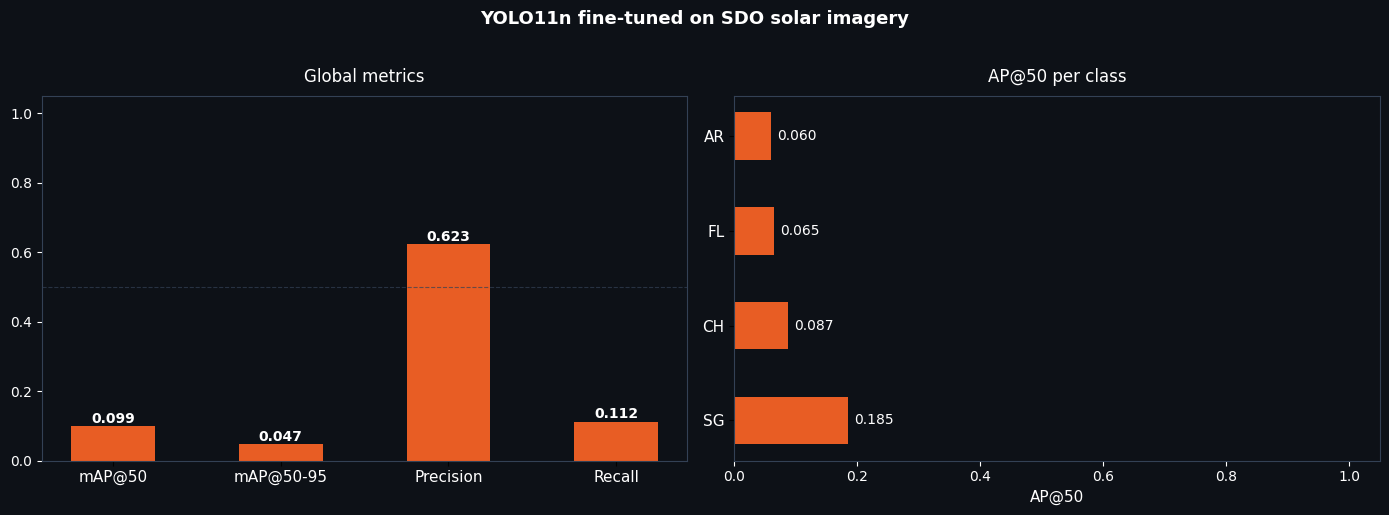

Figure saved ✓


In [19]:
# Metrics visualization
per_class = {
    class_names[idx]: float(ap50)
    for idx, ap50 in zip(results.box.ap_class_index, results.box.ap50)
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=PALETTE["bg"])

# Global metrics
ax1 = axes[0]
ax1.set_facecolor(PALETTE["bg"])
metric_names = ["mAP@50", "mAP@50-95", "Precision", "Recall"]
metric_vals  = [results.box.map50, results.box.map,
                results.box.mp,    results.box.mr]
bars = ax1.bar(metric_names, metric_vals,
               color=PALETTE["orange"], edgecolor="none", width=0.5)
for bar, val in zip(bars, metric_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01, f"{val:.3f}",
             ha="center", color=PALETTE["white"],
             fontsize=10, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.set_xticklabels(metric_names, color=PALETTE["white"], fontsize=11)
ax1.tick_params(axis="y", colors=PALETTE["white"])
ax1.spines[:].set_color(PALETTE["gray"])
ax1.set_title("Global metrics", color=PALETTE["white"], fontsize=12, pad=10)
ax1.axhline(0.5, color=PALETTE["gray"], linestyle="--",
            linewidth=0.8, alpha=0.7)

# Per-class AP
ax2 = axes[1]
ax2.set_facecolor(PALETTE["bg"])
sorted_pairs = sorted(per_class.items(), key=lambda x: -x[1])
cls_names_sorted, ap_vals = zip(*sorted_pairs)
y_pos = np.arange(len(cls_names_sorted))
ax2.barh(y_pos, ap_vals, color=PALETTE["orange"],
         edgecolor="none", height=0.5)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(cls_names_sorted, color=PALETTE["white"], fontsize=11)
ax2.set_xlim(0, 1.05)
ax2.tick_params(axis="x", colors=PALETTE["white"])
ax2.spines[:].set_color(PALETTE["gray"])
ax2.set_xlabel("AP@50", color=PALETTE["white"], fontsize=11)
ax2.set_title("AP@50 per class", color=PALETTE["white"], fontsize=12, pad=10)
for i, val in enumerate(ap_vals):
    ax2.text(val + 0.01, i, f"{val:.3f}", va="center",
             color=PALETTE["white"], fontsize=10)

fig.suptitle("YOLO11n fine-tuned on SDO solar imagery",
             color=PALETTE["white"], fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(OUT_DIR / "metrics_sdo.png", dpi=150,
            bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("Figure saved ✓")

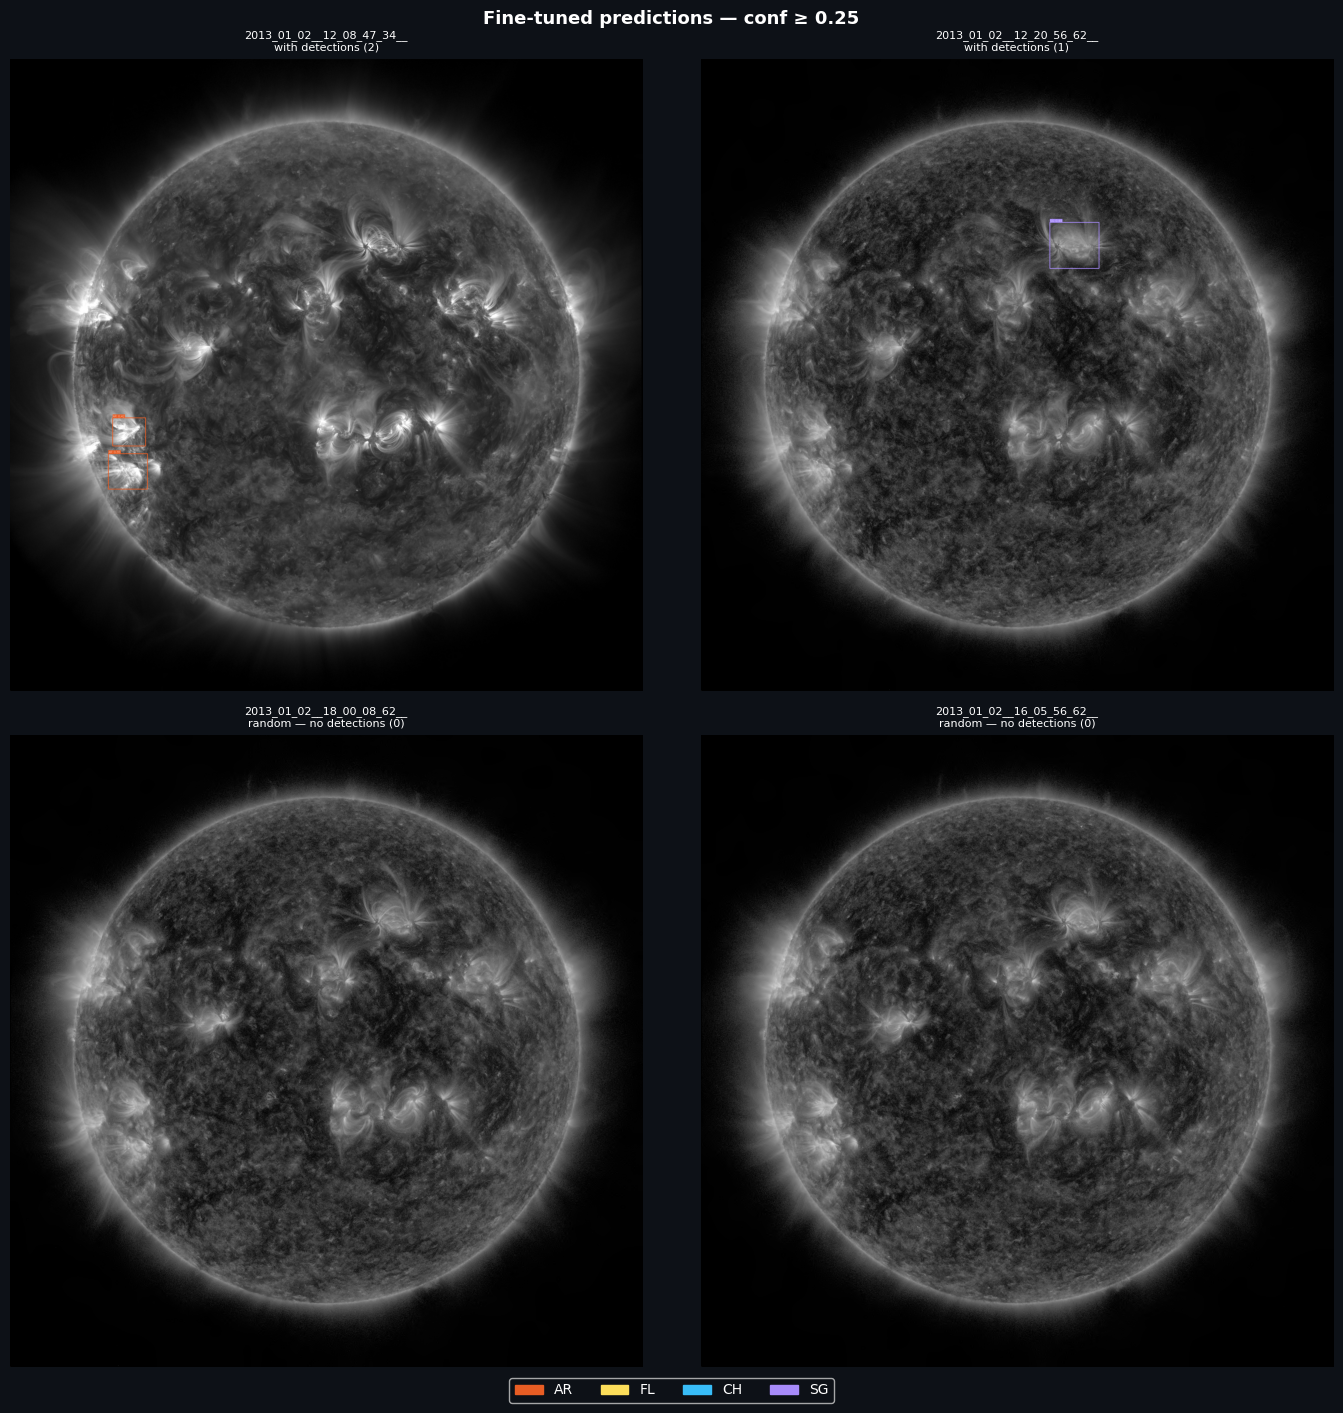

Grid saved ✓


In [20]:
# Visual predictions on val images
# Show 2 images with detections + 2 random images
val_imgs_all = sorted((YOLO_DIR / "images" / "val").glob("*.png"))

pred_results_all = model_ft.predict(
    source=[str(p) for p in val_imgs_all],
    conf=CONF_THRESH,
    iou=IOU_THRESH,
    imgsz=IMGSZ,
    verbose=False,
)

# Separate images with detections from those without
with_detections = [
    (img_path, res) for img_path, res in zip(val_imgs_all, pred_results_all)
    if res.boxes is not None and len(res.boxes) > 0
]
without_detections = [
    (img_path, res) for img_path, res in zip(val_imgs_all, pred_results_all)
    if res.boxes is None or len(res.boxes) == 0
]

import random
selected = with_detections[:2] + random.sample(
    without_detections,
    min(2, len(without_detections))
)
selected_imgs  = [s[0] for s in selected]
selected_preds = [s[1] for s in selected]

N_VIZ = len(selected)
fig, axes = plt.subplots(2, 2, figsize=(14, 14), facecolor=PALETTE["bg"])
axes = axes.flatten()

for ax, img_path, res in zip(axes, selected_imgs, selected_preds):
    img = np.array(Image.open(img_path).convert("RGB"))

    if res.boxes is not None and len(res.boxes):
        for box in res.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            cls_id    = int(box.cls[0])
            conf      = float(box.conf[0])
            cls_name  = class_names[cls_id] if cls_id < len(class_names) else f"cls_{cls_id}"
            color_hex = CLASS_COLORS.get(cls_name, "#FFFFFF")
            color_rgb = tuple(int(color_hex.lstrip("#")[i:i+2], 16)
                              for i in (0, 2, 4))
            cv2.rectangle(img, (x1, y1), (x2, y2), color_rgb, 3)
            label = f"{cls_name} {conf:.2f}"
            (tw, th), _ = cv2.getTextSize(
                label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
            cv2.rectangle(img, (x1, y1 - th - 8),
                          (x1 + tw + 4, y1), color_rgb, -1)
            cv2.putText(img, label, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                        (255, 255, 255), 1)

    n_det = len(res.boxes) if res.boxes is not None else 0
    label = "with detections" if n_det > 0 else "random — no detections"
    ax.imshow(img)
    ax.set_title(f"{img_path.stem[:25]}\n{label} ({n_det})",
                 color=PALETTE["white"], fontsize=8)
    ax.axis("off")
    ax.set_facecolor(PALETTE["bg"])

legend_handles = [
    patches.Patch(color=color, label=cls)
    for cls, color in CLASS_COLORS.items()
]
fig.legend(handles=legend_handles, loc="lower center", ncol=4,
           facecolor=PALETTE["bg"], labelcolor=PALETTE["white"],
           fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"Fine-tuned predictions — conf ≥ {CONF_THRESH}",
             color=PALETTE["white"], fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "predictions_sdo.png", dpi=150,
            bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()
print("Grid saved ✓")

## 8. Summary

### What this notebook demonstrated

The LSDO dataset already contains the two ingredients needed to train an
object detector — high-resolution solar images and annotated bounding boxes
for four classes of solar features (AR, FL, CH, SG). No additional
labeling effort was required. Applying the same fine-tuning pipeline used
on VisDrone produced a model capable of detecting solar features directly
from SDO imagery.

This demonstrates a concrete instance of the channel's central argument:
the data infrastructure that astrophysicists build for scientific purposes
is directly usable for industry-grade computer vision pipelines. The same
technique that powers aerial surveillance, autonomous vehicles, and medical
imaging works on solar physics data with no architectural changes.

### Why these results are not publication-ready

1. **Temporal data leakage:** The three-day sample means train and val
   images share the same solar features. The model is effectively evaluated
   on data it has already seen in a different form. Reported metrics are
   optimistic by an unknown margin.
2. **Sample size:** 322 images from three consecutive days is insufficient
   to learn a generalizable representation of solar feature morphology
   across different solar activity levels, viewing geometries, and
   instrument calibration states.
3. **Single wavelength dominance:** The sample mixes AIA 171Å and 193Å
   images without controlling for wavelength. Different wavelengths
   emphasize different coronal structures — a model trained on mixed
   wavelengths without wavelength conditioning will produce inconsistent
   detections.

### What a rigorous version would require

- Data spanning at least 6 months of the full LSDO dataset (2012-2014)
- Temporally stratified train/val split with at least one solar rotation
  (~27 days) of separation between splits
- Separate models or wavelength conditioning for each AIA channel
- Evaluation against existing solar feature catalogs (HEK) for external
  validation beyond held-out mAP

See the notebook header for minimum computational resource estimates for
this experiment.

### What comes next

The next notebook in this series takes the fine-tuned model and deploys
it as a production API — containerized with Docker, mounted on cloud
infrastructure, and monitored in production. This is the MLOps notebook,
where the astronomical application becomes the vehicle for teaching
industry-standard deployment practices.